# 3 &middot; Elastic Energy Intuition

The deformation gradient $F$ says *how* a triangle is deformed; an **elastic energy density** $\psi(F)$ turns that into one number, *how much* it costs. We write three classics out by hand (linear elasticity, ARAP and Neo-Hookean), push a single triangle through translation, scale, shear, rotation and collapse, and watch each energy respond. A good energy is zero for rigid motions and grows with genuine deformation: linear elasticity fails the rotation test, and Neo-Hookean blows up as the triangle is crushed flat.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
import simkit
import utils

NOTEBOOK = "003_elastic_energy"                                    # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)               # results/003_elastic_energy/
MEDIA_DIR = "media"                                                # tracked copies for the website
# material (Lame parameters)
MU = 1.0                  # shear modulus
LAM = 1.0                 # first Lame parameter (resists area change)
LAM_STIFF = 50.0          # nearly incompressible lambda for the collapse test
# deformation sweeps
MAX_SHIFT = 3.0           # largest translation distance
N_SHIFT = 40              # translation samples
SCALE_MIN = 0.5           # smallest uniform scale factor
SCALE_MAX = 1.8           # largest uniform scale factor
N_SCALE = 50              # scale samples
MAX_SHEAR = 1.6           # largest shear amount k
N_SHEAR = 50              # shear samples
N_ROTATION = 60           # rotation samples over one full turn
COLLAPSE_DECADES = 9.0    # the apex height shrinks to 10^-COLLAPSE_DECADES of its rest value
N_COLLAPSE = 50           # collapse samples
FPS = 20                  # animation frame rate
# energy landscape over principal stretches
STRETCH_MIN = 0.02        # smallest principal stretch on the grid
STRETCH_MAX = 2.0         # largest principal stretch on the grid
N_STRETCH = 60            # grid samples per axis
# forces figure: one representative amount of each motion
SHOW_SHIFT = 0.8          # translation distance
SHOW_ANGLE = np.pi / 2    # rotation angle
SHOW_SCALE = 1.4          # uniform scale factor
SHOW_SHEAR = 0.8          # shear amount k
MAX_ARROW = 0.8           # drawn length of the largest force arrow
# validation against simkit
N_RANDOM = 200            # random deformed triangles
NOISE = 0.3               # size of the random vertex perturbation
FD_STEP = 1e-6            # central-difference step
ZERO_EIG_TOL = 1e-4       # Hessian eigenvalues below this fraction of the largest count as zero
SEED = 0                  # random seed

## The three energies, written out

Each density is a function of $F$ alone, with Lamé constants $\mu$ (shear) and $\lambda$ (area change). The next cell transcribes them, one named term per line.

* **Linear elasticity**, with the small-strain tensor $\varepsilon = \tfrac12(F+F^\top) - I$: $\;\psi = \mu\lVert\varepsilon\rVert_F^2 + \tfrac{\lambda}{2}\,\mathrm{tr}(\varepsilon)^2$.
* **ARAP**, with $R$ the rotation of the polar decomposition $F = RS$: $\;\psi = \tfrac{\mu}{2}\lVert F - R\rVert_F^2$, the distance to the *nearest rotation* (simkit's normalization).
* **Neo-Hookean**, with $I_C = \lVert F\rVert_F^2$ and the area ratio $J = \det F$: $\;\psi = \tfrac{\mu}{2}(I_C - 2) - \mu\ln J + \tfrac{\lambda}{2}(\ln J)^2$. The barrier $-\mu\ln J \to +\infty$ as $J \to 0$, so the material cannot be crushed to zero area.

In [2]:
def linear_energy(F, mu, lam):
    eps = 0.5 * (F + F.T) - np.eye(2)                    # small-strain tensor
    E_shear = mu * np.sum(eps**2)                        # deviatoric (shape) term
    E_volume = 0.5 * lam * np.trace(eps)**2              # volumetric term
    E_total = E_shear + E_volume
    return E_total

def arap_energy(F, mu, lam):
    R = simkit.polar_svd(F)[0][0]                        # nearest rotation to F
    E_shape = 0.5 * mu * np.sum((F - R)**2)              # distance to that rotation
    E_total = E_shape                                    # single term: ARAP ignores lam
    return E_total

def neo_hookean_energy(F, mu, lam):
    I_C = np.sum(F**2)                                   # first invariant ||F||^2
    J = np.linalg.det(F)                                 # area ratio
    E_shear = 0.5 * mu * (I_C - 2)                       # resists shearing / stretching
    E_barrier = -mu * np.log(J)                          # forbids crushing (J -> 0)
    E_volume = 0.5 * lam * np.log(J)**2                  # resists area change
    E_total = E_shear + E_barrier + E_volume
    return E_total

ENERGIES = {"Linear": linear_energy, "ARAP": arap_energy, "Neo-Hookean": neo_hookean_energy}

The rest shape is a single equilateral triangle with a unit base (vertex ids shown). It has no pins or handles: every deformation below is prescribed, and we evaluate its energy (and, at the end, the forces it produces).

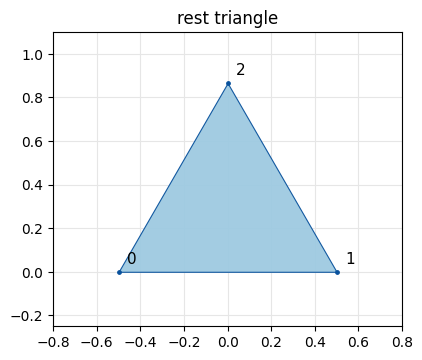

In [3]:
X = np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])   # rest vertices
T = np.array([[0, 1, 2]])                                          # one triangle

fig, ax = plt.subplots(figsize=(4.5, 4))
utils.plot_mesh(ax, X, T, title="rest triangle", show_vertices=True, lims=((-0.8, 0.8), (-0.25, 1.1)))
for i, p in enumerate(X):
    ax.annotate(str(i), p, xytext=(6, 6), textcoords="offset points", fontsize=11)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "rest_triangle.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_rest_triangle.png"))
plt.show()

The motions are maps applied to the rest vertices. `sweep_energies` gets each deformed copy's $F$ from `simkit.deformation_gradient` and evaluates every energy density on it.

In [4]:
def translate(X, t):
    return X + np.asarray(t, float)

def rotate(X, theta):
    c, s = np.cos(theta), np.sin(theta)
    return X @ np.array([[c, -s], [s, c]]).T

def scale(X, s):
    return X * s

def shear(X, k):
    return X @ np.array([[1.0, k], [0.0, 1.0]]).T

def sweep_energies(states, mu, lam):
    """Energy density of every material for each deformed triangle in `states`."""
    series = {name: np.zeros(len(states)) for name in ENERGIES}
    for i, U in enumerate(states):
        F = simkit.deformation_gradient(X, T, U)[0]
        for name, psi in ENERGIES.items():
            series[name][i] = psi(F, mu, lam)
    return series

## Translation costs no energy

Sliding the triangle keeps $F = I$, so every energy stays flat at zero (the three curves coincide, so only the green one shows). The cell draws the static curve, then an animation with the triangle on the left (rest shape ghosted, view fitted to every frame) and the energies traced on the right; the y-axis is fixed so the flat line does not zoom into round-off.

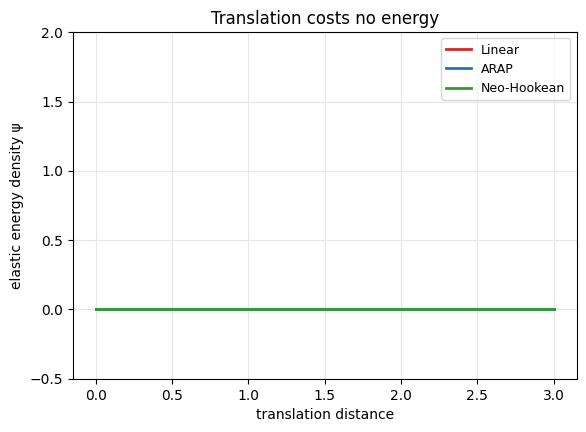

In [5]:
shifts = np.linspace(0, MAX_SHIFT, N_SHIFT)
states = [translate(X, [d, 0.0]) for d in shifts]
series = sweep_energies(states, MU, LAM)

fig, ax = utils.line_plot(shifts, series, xlabel="translation distance", ylabel="elastic energy density ψ",
                          title="Translation costs no energy", ylim=(-0.5, 2.0))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "translation.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_translation.png"))
plt.show()

fig, anim = utils.animate_scene_energy(states, shifts, series, rest=X, xlabel="translation distance",
                                       lims=utils.auto_limits(states), scene_title="triangle sliding",
                                       title="energy vs translation", energy_ylim=(-0.5, 2.0), fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "translation.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "003_translation.mp4"))
plt.close(fig)
utils.embed_video(video)

## Scale: every energy grows

Uniform scaling $F = sI$ genuinely deforms the material, so all three energies rise away from $s = 1$. Neo-Hookean is the stiffest in compression ($s < 1$, where its barrier starts to act) and linear elasticity the stiffest in stretch.

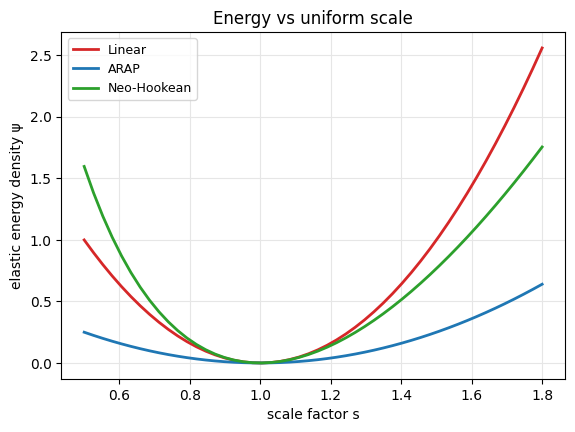

In [6]:
scales = np.linspace(SCALE_MIN, SCALE_MAX, N_SCALE)
states = [scale(X, s) for s in scales]
series = sweep_energies(states, MU, LAM)

fig, ax = utils.line_plot(scales, series, xlabel="scale factor s", ylabel="elastic energy density ψ",
                          title="Energy vs uniform scale")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "scale.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_scale.png"))
plt.show()

fig, anim = utils.animate_scene_energy(states, scales, series, rest=X, xlabel="scale factor s",
                                       scene_title="triangle scaling", title="energy vs scale", fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "scale.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "003_scale.mp4"))
plt.close(fig)
utils.embed_video(video)

## Shear: every energy grows too

Shear $F = \begin{pmatrix}1 & k\\ 0 & 1\end{pmatrix}$ changes shape but not area ($J = 1$), so only the shear terms act. Linear elasticity and Neo-Hookean give exactly the same curve, $\mu k^2/2$ (the green curve hides the red one), and ARAP is about half of it because of its $\tfrac{\mu}{2}$ normalization.

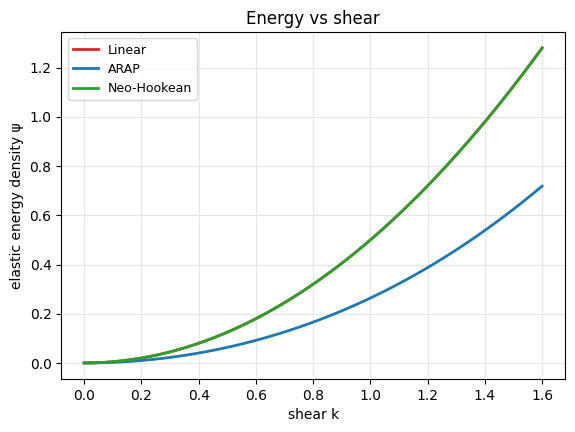

In [7]:
shears = np.linspace(0.0, MAX_SHEAR, N_SHEAR)
states = [shear(X, k) for k in shears]
series = sweep_energies(states, MU, LAM)

fig, ax = utils.line_plot(shears, series, xlabel="shear k", ylabel="elastic energy density ψ",
                          title="Energy vs shear")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "shear.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_shear.png"))
plt.show()

fig, anim = utils.animate_scene_energy(states, shears, series, rest=X, xlabel="shear k",
                                       scene_title="triangle shearing", title="energy vs shear", fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "shear.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "003_shear.mp4"))
plt.close(fig)
utils.embed_video(video)

## Rotation: linear elasticity is *not* rotation-invariant

Now the surprise: spin the triangle through a full turn. **ARAP** and **Neo-Hookean** stay at zero (the green curve hides the blue one), rotation is free. **Linear elasticity** rises to $16$ at $\theta = \pi$ and falls back: its small-strain tensor $\varepsilon$ mistakes rotation for stretch ($F = -I$ gives $\varepsilon = -2I$). This is why linear elasticity is only valid for *tiny* deformations.

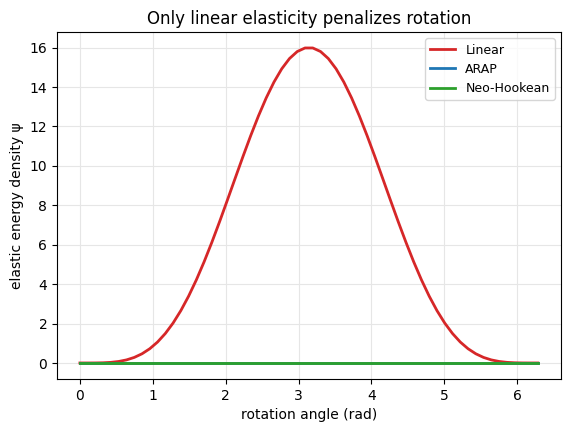

In [8]:
angles = np.linspace(0, 2 * np.pi, N_ROTATION)
states = [rotate(X, a) for a in angles]
series = sweep_energies(states, MU, LAM)

fig, ax = utils.line_plot(angles, series, xlabel="rotation angle (rad)", ylabel="elastic energy density ψ",
                          title="Only linear elasticity penalizes rotation")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "rotation.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_rotation.png"))
plt.show()

fig, anim = utils.animate_scene_energy(states, angles, series, rest=X, xlabel="rotation angle (rad)",
                                       scene_title="triangle rotating", title="energy vs rotation angle", fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "rotation.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "003_rotation.mp4"))
plt.close(fig)
utils.embed_video(video)

## Crushing the triangle flat: Neo-Hookean $\to \infty$

Drive the apex straight down onto the base, so $F = \mathrm{diag}(1, r)$ and the area ratio $J = r \to 0$. The blow-up is only *logarithmic*, $\psi \approx \tfrac{\lambda}{2}(\ln J)^2 - \mu\ln J$, so to see it we collapse hard, $r = 10^{-9t}$ (down to $J \sim 10^{-9}$), with a nearly incompressible material ($\lambda = 50$), and plot on a log axis. The rest shape ($t = 0$, $\psi = 0$) is left off the plots, since a log axis cannot show zero. The cell prints $J$ and the Neo-Hookean energy at full collapse.

det F at full collapse: 1.00e-09   Neo-Hookean energy: 10757


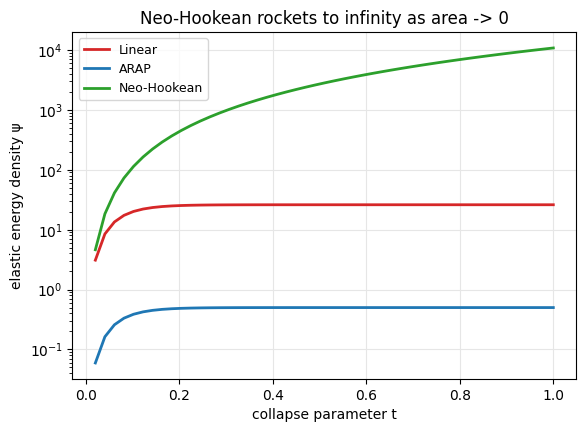

In [9]:
y0 = X[2, 1]                                                  # rest apex height

def collapse_apex(t):
    U = X.copy()
    U[2, 1] = y0 * 10.0**(-COLLAPSE_DECADES * t)              # apex height shrinks log-uniformly
    return U

ts = np.linspace(0, 1, N_COLLAPSE)
states = [collapse_apex(t) for t in ts]
series = sweep_energies(states, MU, LAM_STIFF)
J_end = np.linalg.det(simkit.deformation_gradient(X, T, states[-1])[0])
print(f"det F at full collapse: {J_end:.2e}   Neo-Hookean energy: {series['Neo-Hookean'][-1]:.0f}")

plotted = {name: psi[1:] for name, psi in series.items()}      # drop the rest sample (psi = 0)
fig, ax = utils.line_plot(ts[1:], plotted, xlabel="collapse parameter t", ylabel="elastic energy density ψ",
                          logy=True, title="Neo-Hookean rockets to infinity as area -> 0")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "collapse.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_collapse.png"))
plt.show()

fig, anim = utils.animate_scene_energy(states[1:], ts[1:], plotted, rest=X, xlabel="collapse parameter t",
                                       scene_title="apex crushed onto the base", title="energy vs collapse",
                                       logy=True, fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "collapse.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "003_collapse.mp4"))
plt.close(fig)
utils.embed_video(video)

Neo-Hookean reaches $\sim 10^4$ and is still climbing toward $+\infty$, while ARAP sits at a finite plateau (it has no area term) and linear elasticity stays modest.

## The whole picture: $\psi$ over the principal stretches

Scale and collapse both keep $F$ diagonal, $F = \mathrm{diag}(s_1, s_2)$, so we can map each energy density over the $(s_1, s_2)$ plane (with $\lambda = 1$, log colour scale). The dashed diagonal is the scale sweep, the dotted vertical line the collapse, and the star the rest shape, where every energy is zero.

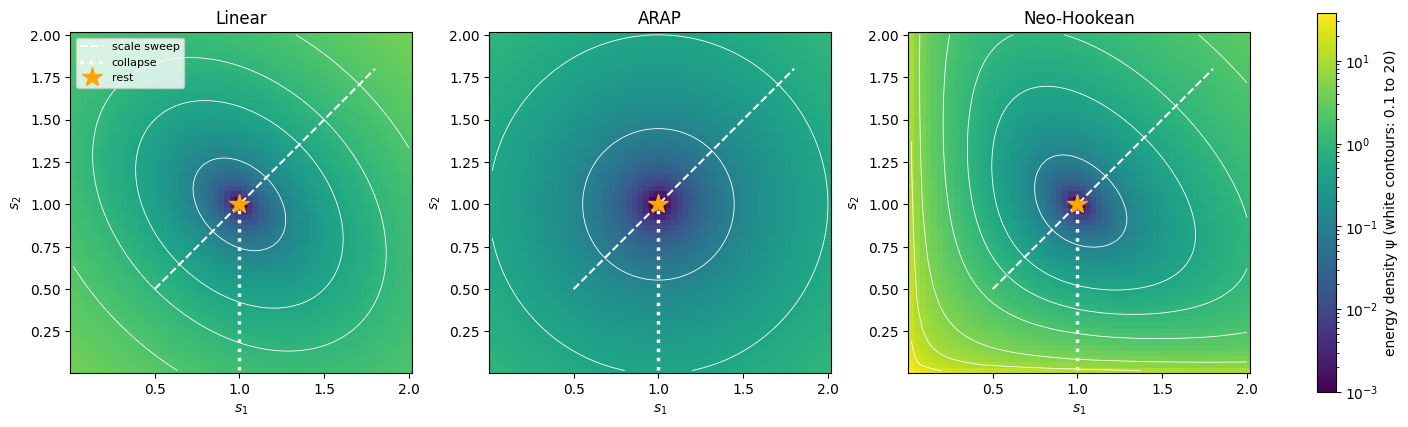

In [10]:
stretches = np.linspace(STRETCH_MIN, STRETCH_MAX, N_STRETCH)
S1, S2 = np.meshgrid(stretches, stretches)
density = {name: np.array([[psi(np.diag([a, b]), MU, LAM) for a in stretches] for b in stretches])
           for name, psi in ENERGIES.items()}
norm = LogNorm(vmin=1e-3, vmax=max(d.max() for d in density.values()))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)
for ax, (name, d) in zip(axes, density.items()):
    mappable = ax.pcolormesh(S1, S2, np.maximum(d, 1e-3), norm=norm, cmap="viridis", shading="auto")
    ax.contour(S1, S2, d, levels=[0.1, 0.5, 1, 2, 5, 10, 20], colors="w", linewidths=0.6)
    ax.plot([SCALE_MIN, SCALE_MAX], [SCALE_MIN, SCALE_MAX], "w--", lw=1.5, label="scale sweep")
    ax.plot([1, 1], [STRETCH_MIN, 1], "w:", lw=2.5, label="collapse")
    ax.plot(1, 1, "*", color="orange", ms=15, label="rest")
    ax.set(title=name, xlabel="$s_1$", ylabel="$s_2$", aspect="equal")
axes[0].legend(loc="upper left", fontsize=8)
fig.colorbar(mappable, ax=axes, shrink=0.9, label="energy density ψ (white contours: 0.1 to 20)")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "stretch_landscape.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_stretch_landscape.png"))
plt.show()

Linear elasticity is a smooth bowl that stays finite even as $s_1 s_2 \to 0$, ARAP is a shallow bowl around $(1, 1)$, and Neo-Hookean climbs steeply along both axes, where $J = s_1 s_2 \to 0$.

## From energy to forces: the triangle as a simkit system

Later notebooks minimize energies with Newton's method, which needs the energy, gradient and Hessian with respect to the stacked vertex positions $x$. `triangle_system` builds all three from simkit: `simkit.deformation_jacobian` maps $x$ to $F$, the rest area is the quadrature weight, and simkit's material library supplies $\psi$, so $E(x) = \text{area}\cdot\psi(F)$.

In [11]:
MATERIALS = {"Linear": "linear-elasticity", "ARAP": "arap", "Neo-Hookean": "neo-hookean"}   # simkit names

def triangle_system(X, T, material, mu, lam):
    """Elastic energy of the rest mesh (X, T) as a function of stacked positions x, built from simkit."""
    n, dim = X.shape
    J = simkit.deformation_jacobian(X, T)          # maps x to the stacked entries of F
    vol = simkit.volume(X, T)                      # rest area of each triangle
    mu_e = np.full((len(T), 1), mu)                # per-element Lame parameters
    lam_e = np.full((len(T), 1), lam)

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu_e, lam_e, vol, material)
        E_total = E_elastic
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu_e, lam_e, vol, material)
        g_total = g_elastic
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu_e, lam_e, vol, material, psd=True)
        H_total = H_elastic
        return H_total

    return energy_func, gradient_func, hessian_func

systems = {name: triangle_system(X, T, material, MU, LAM) for name, material in MATERIALS.items()}

A check before trusting it, on random non-inverted deformations of the triangle: area $\times$ our one-line $\psi$ should equal simkit's energy (plotted, one dot per sample), simkit's gradient should match central differences (`simkit.gradient_cfd`), and the Hessian at rest should have exactly three (numerically) zero eigenvalues, the rigid motions: two translations and one infinitesimal rotation.

194 non-inverted samples
Linear       max |E_ours - E_simkit| = 0.0e+00   FD gradient rel. error = 5.9e-11   zero Hessian eigenvalues at rest = 3
ARAP         max |E_ours - E_simkit| = 0.0e+00   FD gradient rel. error = 2.9e-10   zero Hessian eigenvalues at rest = 3
Neo-Hookean  max |E_ours - E_simkit| = 4.4e-16   FD gradient rel. error = 1.1e-10   zero Hessian eigenvalues at rest = 3


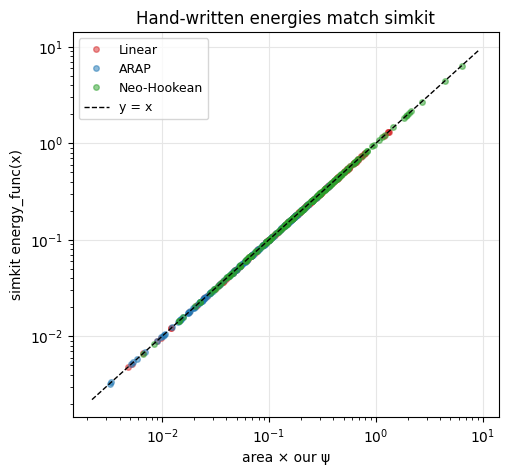

In [12]:
rng = np.random.default_rng(SEED)
area = simkit.volume(X, T)[0, 0]
samples = [X + NOISE * rng.standard_normal(X.shape) for _ in range(N_RANDOM)]
samples = [U for U in samples if np.linalg.det(simkit.deformation_gradient(X, T, U)[0]) > 0]
x_test = samples[0].reshape(-1, 1)
print(f"{len(samples)} non-inverted samples")

fig, ax = plt.subplots(figsize=(5.5, 5))
for name, (energy_func, gradient_func, hessian_func) in systems.items():
    E_ours = np.array([area * ENERGIES[name](simkit.deformation_gradient(X, T, U)[0], MU, LAM) for U in samples])
    E_simkit = np.array([energy_func(U.reshape(-1, 1)) for U in samples])
    g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y)), x_test, FD_STEP)
    g_err = np.linalg.norm(g_fd - gradient_func(x_test).ravel()) / np.linalg.norm(g_fd)
    H_rest = hessian_func(X.reshape(-1, 1)).toarray()
    eigs = np.linalg.eigvalsh(H_rest)
    n_zero = np.sum(np.abs(eigs) < ZERO_EIG_TOL * eigs.max())
    print(f"{name:12s} max |E_ours - E_simkit| = {np.abs(E_ours - E_simkit).max():.1e}   "
          f"FD gradient rel. error = {g_err:.1e}   zero Hessian eigenvalues at rest = {n_zero}")
    ax.loglog(E_ours, E_simkit, "o", ms=4, alpha=0.5, color=utils.MAT_COLORS[name], label=name)
lo, hi = ax.get_xlim()
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax.set(xlabel="area × our ψ", ylabel="simkit energy_func(x)", title="Hand-written energies match simkit")
ax.grid(True, color="0.9")
ax.legend(fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "simkit_check.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_simkit_check.png"))
plt.show()

All three agree with simkit to round-off and lie on the diagonal, the gradients match finite differences to about $10^{-10}$, and every Hessian has the three rigid null modes. Note that linear elasticity passes this *infinitesimal* rotation test; it only fails for finite rotations.

The negative gradient $-\partial E/\partial x$ is the elastic force on each vertex. Below, each row is a material and each column one motion; the triangle is coloured by its energy density $\psi$ (`utils.plot_scalar_field`), the dashed outline is the rest shape, and the arrows (one shared scale) are the vertex forces, with the largest magnitude printed in each panel.

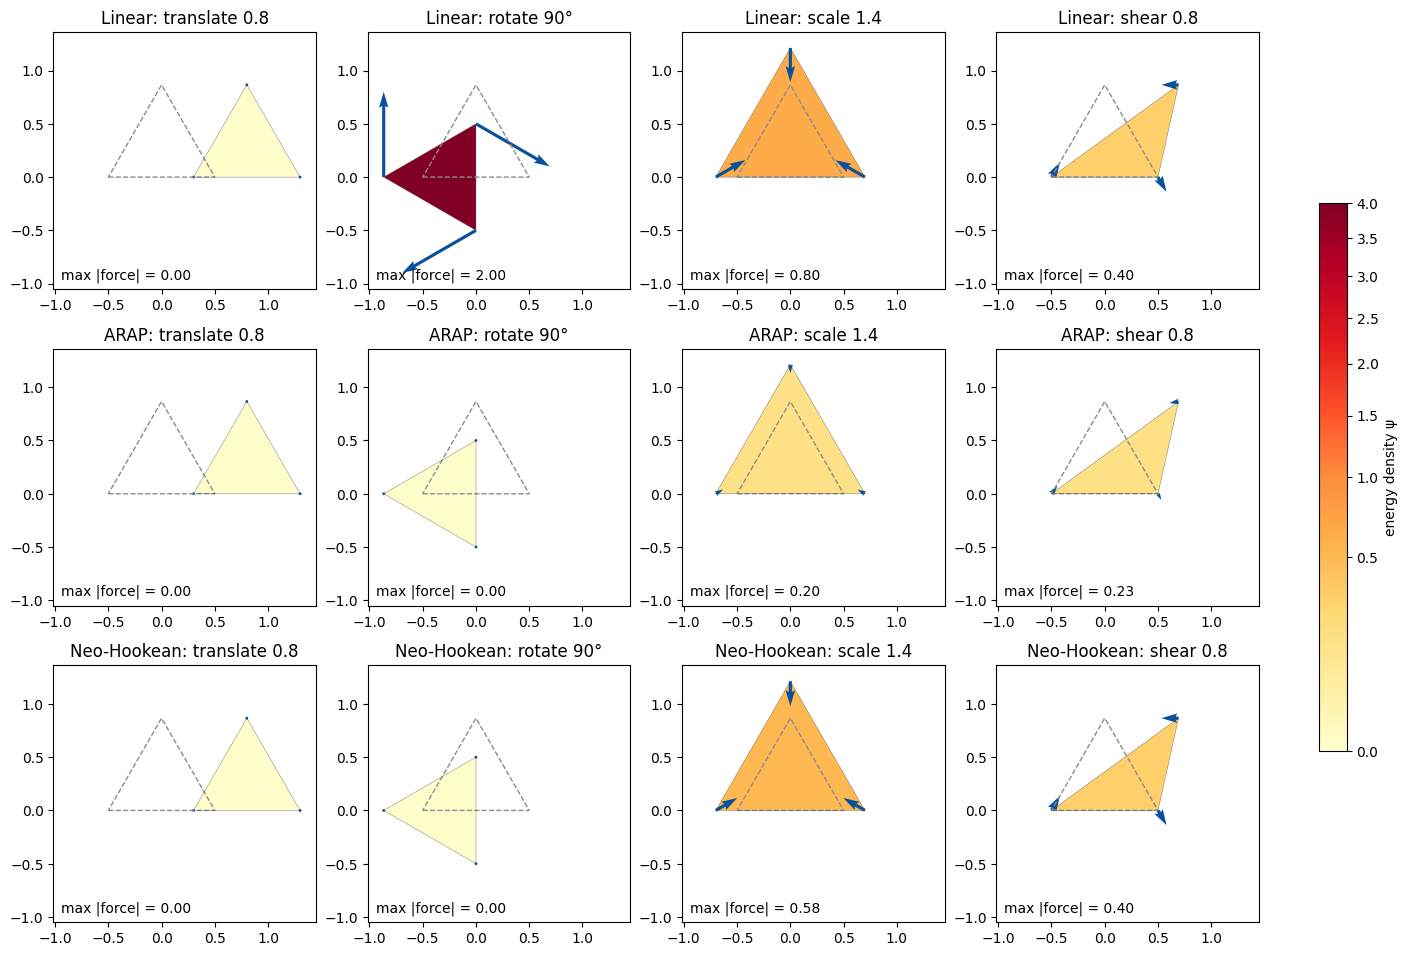

In [13]:
motions = {f"translate {SHOW_SHIFT}": translate(X, [SHOW_SHIFT, 0.0]),
           f"rotate {np.degrees(SHOW_ANGLE):.0f}°": rotate(X, SHOW_ANGLE),
           f"scale {SHOW_SCALE}": scale(X, SHOW_SCALE),
           f"shear {SHOW_SHEAR}": shear(X, SHOW_SHEAR)}
psi_show, force_show = {}, {}
for name, (energy_func, gradient_func, hessian_func) in systems.items():
    for m, U in motions.items():
        psi_show[name, m] = ENERGIES[name](simkit.deformation_gradient(X, T, U)[0], MU, LAM)
        force_show[name, m] = -gradient_func(U.reshape(-1, 1)).reshape(-1, 2)       # force = -dE/dx
arrow_scale = max(np.linalg.norm(f, axis=1).max() for f in force_show.values()) / MAX_ARROW   # force per unit length
norm = PowerNorm(gamma=0.5, vmin=0.0, vmax=max(psi_show.values()))
arrow_tips = [U + force_show[name, m] / arrow_scale for name in systems for m, U in motions.items()]
lims = utils.auto_limits(list(motions.values()) + arrow_tips + [X], pad=0.15)
rest_outline = np.vstack([X, X[:1]])

fig, axes = plt.subplots(3, 4, figsize=(14, 9.5), constrained_layout=True)
for row, name in zip(axes, systems):
    for ax, (m, U) in zip(row, motions.items()):
        mappable = utils.plot_scalar_field(ax, U, T, [psi_show[name, m]], norm=norm, cmap="YlOrRd",
                                           colorbar=False, lims=lims, title=f"{name}: {m}")
        ax.plot(rest_outline[:, 0], rest_outline[:, 1], "--", color="0.55", lw=1)
        f = force_show[name, m]
        ax.quiver(U[:, 0], U[:, 1], f[:, 0], f[:, 1], angles="xy", scale_units="xy", scale=arrow_scale,
                  color="#08519c", width=0.012)
        ax.text(0.03, 0.04, f"max |force| = {np.linalg.norm(f, axis=1).max():.2f}", transform=ax.transAxes)
fig.colorbar(mappable, ax=axes, shrink=0.6, label="energy density ψ")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "forces.png"),
                              copy_to=os.path.join(MEDIA_DIR, "003_forces.png"))
plt.show()

Translation costs nothing and produces no force for any material. Rotation is also force-free for ARAP and Neo-Hookean, but linear elasticity lights up ($\psi = 4$) and pushes the rotated vertices with the largest spurious forces in the figure. Scale and shear are resisted by all three, with forces pushing the triangle back toward an undeformed shape; ARAP's are the weakest, since it has the $\tfrac{\mu}{2}$ factor and no area term.

### Takeaways
* Each energy is one line of math: linear (small strain), ARAP ($\tfrac{\mu}{2}$ distance to the nearest rotation), Neo-Hookean (with the $-\mu\ln J$ barrier), and each matches simkit's material library to round-off.
* Good energies are zero, and exert no force, for rigid motions, and grow with scale and shear.
* **Linear** breaks rotation invariance for finite rotations; **Neo-Hookean** diverges at collapse; **ARAP** stays finite.
* Next: minimize an energy (plus constraints) with Newton's method, using `XXX_system` energy, gradient and Hessian functions like `triangle_system`, to actually *pose* a shape.